# Dimensionality Reduction

## PCA

Here is an example of how decrease number of dimensions in $3D$ dataset via singular matrix decomposition:

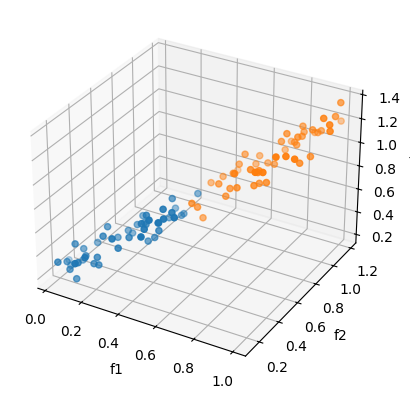

In [51]:
import numpy as np
import matplotlib.pyplot as plt

instances = 100

f1 = np.random.rand(instances)
f2 = f1 + np.random.rand(instances) * 0.2
f3 = f2 + np.random.rand(instances) * 0.2

X = np.c_[f1, f2, f3]
y = (f1 > 0.5).astype(np.int8)


fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.scatter(X[:, 0][y == 0], X[:, 1][y == 0], X[:, 2][y == 0])
ax.scatter(X[:, 0][y == 1], X[:, 1][y == 1], X[:, 2][y == 1])

ax.set_xlabel('f1')
ax.set_ylabel('f2')
ax.set_zlabel('f3')

plt.show()

In [52]:
def plot_PCA_projection(keep_dims: int, X, y) -> None:
    X_centered = X - X.mean(axis=0)
    U, s, V = np.linalg.svd(X_centered)
    V = V.T

    X_projected = X @ V[:, :keep_dims]

    if keep_dims == 2:
        plt.scatter(X_projected[:, 0][y == 0], X_projected[:, 1][y == 0])
        plt.scatter(X_projected[:, 0][y == 1], X_projected[:, 1][y == 1])
        plt.show()
    elif keep_dims == 1:
        plt.scatter(X_projected[:, 0][y == 0], np.zeros(X_projected[:, 0][y == 0].shape), alpha=0.3)
        plt.scatter(X_projected[:, 0][y == 1], np.zeros(X_projected[:, 0][y == 1].shape), alpha=0.3)
        plt.show()
    else:
        print("Unsupported keep_dims for 3D dataset")

def plot_2D_binary_clf(X, y) -> None:
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0])
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1])
    plt.show()

def plot_1D_binary_clf(X, y) -> None:
    plt.scatter(X[:, 0][y == 0], np.zeros(X[:, 0][y == 0].shape), alpha=0.3)
    plt.scatter(X[:, 0][y == 1], np.zeros(X[:, 0][y ==1].shape), alpha=0.3)
    plt.show()

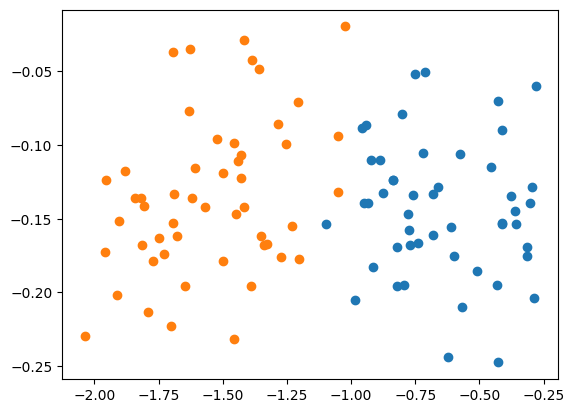

In [53]:
plot_PCA_projection(keep_dims=2, X=X, y=y)

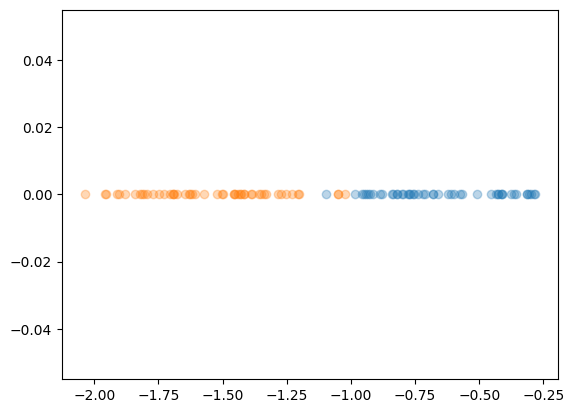

In [54]:
plot_PCA_projection(keep_dims=1, X=X, y=y)

You can also use **SKLearn** class for PCA

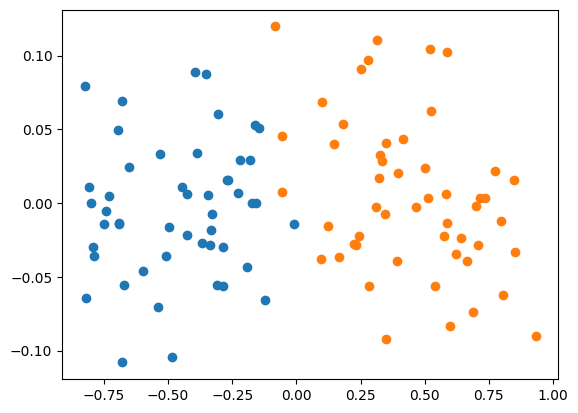

In [55]:
from sklearn.decomposition import PCA

pca2D = PCA(n_components=2)
X_2d = pca2D.fit_transform(X)
plot_2D_binary_clf(X_2d, y)

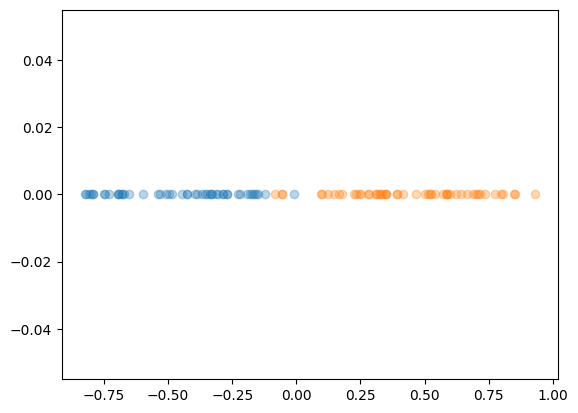

In [56]:
pca1D = PCA(n_components=1)
X_1d = pca1D.fit_transform(X)
plot_1D_binary_clf(X_1d, y)

Explained variance is very useful PCA feature. It allows you to see, what variance has each principal component

In [59]:
pca2D.explained_variance_ratio_

array([0.98718725, 0.00917129])

The output indicates, than only one feature in the dataset actually gives us variance _(information about the data)_. Other features are just linear combinations via the first feature.

Usually, we choose number of principal components that give us $\approx95\%$ of variance. Here is an example on MNIST dataset

In [60]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=True)
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

In [65]:
pca_mnist = PCA()
pca_mnist.fit(X_train)
cumsum = np.cumsum(pca_mnist.explained_variance_ratio_)

d = np.argmax(cumsum >= 0.95) + 1
d

np.int64(154)

Only $154$ features are really important in MNIST! Despite that MNIST contains 784 features...

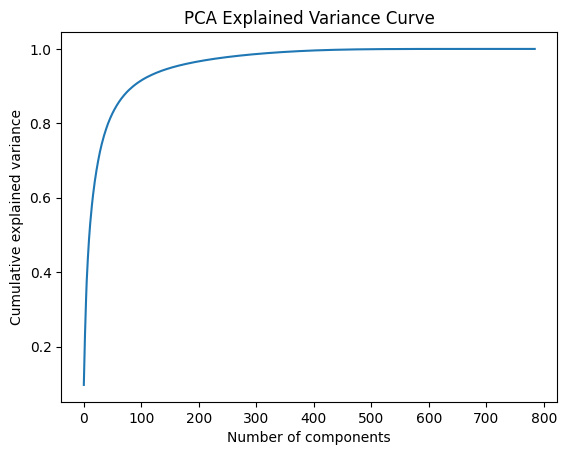

In [69]:
plt.plot(np.linspace(0, cumsum.shape[0], num=cumsum.shape[0]), cumsum)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance Curve")
plt.show()